In [635]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt 
from datetime import datetime as dt
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing 


In [636]:
def get_gleason_group(X, gg_type = 'biopsy'):
    grade_group = np.nan
    if gg_type == 'biopsy':
        gleason_primary = X.bxgg_primary
        gleason_secondary = X.bxgg_secondary
    elif gg_type == 'path':
        gleason_primary = X.pathgg_primary
        gleason_secondary = X.pathgg_secondary

    if gleason_primary + gleason_secondary <= 6:
        grade_group = 1
    elif gleason_primary == 3 and gleason_secondary == 4:
        grade_group = 2 
    elif gleason_primary == 4 and gleason_secondary == 3:
        grade_group = 3
    elif gleason_primary == 4 and gleason_secondary == 4:
        grade_group = 4 
    elif gleason_primary + gleason_secondary >= 9:
        grade_group = 5

    return grade_group

In [637]:
def get_gleason_capra(row):
    if pd.isna(row['bxgg_primary']) | pd.isna(row['bxgg_secondary']):
        gleason_capra = np.nan
    elif row['bxgg_primary'] <= 3 and row['bxgg_secondary'] <= 3:
        gleason_capra = 0
    elif row['bxgg_primary'] <= 3 and 4 <= row['bxgg_secondary'] <= 5:
        gleason_capra = 1
    elif 4 <= row['bxgg_primary'] <= 5 and row['bxgg_secondary'] <= 5:
        gleason_capra = 3
    return gleason_capra

In [638]:
#funtion to remove columns in dataframe whose values match other columns at a percentage higher than a given threshold (th)

def remove_matching_cols(df, th = 1, verbose = True):

    n_features = len(df.columns)
    df_new = df.copy()
    cols_removed = list()

    for feature in df.select_dtypes(include='number').columns:
        if feature in df_new.columns:
            df_temp = df_new.select_dtypes(include='number').drop(labels=feature, axis=1)
            mask_duplicate_cols = df_temp.apply(lambda col: col == df_new[feature]).sum()/len(df) >= th
            cols2drop = list(df_temp.columns[mask_duplicate_cols])
            df_new = df_new.drop(labels=cols2drop, axis=1)
            cols_removed += cols2drop

    if verbose:
        print( f"{n_features - len(df_new.columns)} features were removed: {cols_removed}")

    return df_new


In [639]:
#function to impute and scale dataframe data, based on values from a training set
#- categorical vars are imputed according to most frequent category
#- numerical vars are imputed according to mean
#- scaling is done only on numerical vars using the z-score
#- get dummies from categorical vars 
def impute_and_scale(X, X_train):
    X_train_cat = X_train.loc[:,'psa':].select_dtypes(include='category').copy()
    X_train_num = X_train.loc[:,'psa':].select_dtypes(include='number').copy()

    X_cat = X.loc[:,'psa':].select_dtypes(include='category').copy()
    X_num = X.loc[:,'psa':].select_dtypes(include='number').copy()

    imp_mode = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
    imp_mean = SimpleImputer(missing_values=np.nan, strategy='median')
    scaler = StandardScaler()

    imp_mode.fit(X_train_cat)
    imp_mode.set_output(transform='pandas')

    imp_mean.fit(X_train_num)
    imp_mean.set_output(transform='pandas')


    X_cat = imp_mode.transform(X_cat)
    X_num = imp_mean.transform(X_num)


    label_encoder = preprocessing.LabelEncoder() 
    X_cat = X_cat.apply(lambda x: label_encoder.fit_transform(x))
    #X_cat = pd.get_dummies(X_cat, drop_first=True)

    #scaler.fit(X_train_num)
    #scaler.set_output(transform='pandas')
    #X_num = scaler.transform(X_num)

    X_new = pd.concat([X.loc[:,:'bcr'], X_num.astype(float), X_cat.astype('category')], axis = 1)

    return X_new

In [640]:
df = pd.read_excel("../../../../../MASTER PROSTATA 2024/OUTPUT/Master_Prostate_Milan_2024-09-18.xlsx")

In [641]:
df.set_index('patientID', inplace=True)
df.head()

,dob,age,solvente,familiarita,altezza,peso,bmi,potus,fumo,anti_aggregante,...,btbEF,ttbtbEF,DRS_1,DRS_2,DRS_3,DRS_4,DRS_5,ttDRS,VAS_score,ttVAS
patientID,,,,,,,,,,,,,,,,,,,,,
7,1925-11-10,71.233402,0.0,NaN,170.0,75.0,25.951557,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53,1935-11-10,60.780287,1.0,NaN,NaN,74.0,NaN,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
144,1934-05-06,64.262834,0.0,NaN,178.0,76.0,23.986870,0.0,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
164,1923-11-19,69.418207,0.0,NaN,NaN,65.0,NaN,0.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
204,1955-10-17,57.519507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [642]:
print(f"The dataset has {len(df)} rows with {len(df.index.unique())} unique patient IDs and {len(df.columns)} features")

The dataset has 11181 rows with 11181 unique patient IDs and 438 features


In [643]:
#Check for overall numerosity of missing values values

null_count = np.sum(np.sum(df.isnull()))
nan_count = np.sum(np.sum(df.isna()))
spaces_count = np.sum(np.sum(df.applymap(lambda x: x == ' '), axis = 0))

print(f"The dataset has a total of {null_count} null values, {nan_count} nan values and {spaces_count} space values.")

c:\Users\airoso.alexandre\AppData\Local\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
C:\Users\airoso.alexandre\AppData\Local\Temp\ipykernel_11812\1985424362.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  spaces_count = np.sum(np.sum(df.applymap(lambda x: x == ' '), axis = 0))


The dataset has a total of 3085943 null values, 3085943 nan values and 0 space values.


In [644]:
#Convert spaces to nan for easier data handling
df.replace(' ', np.nan, inplace = True)

null_count = np.sum(np.sum(df.isnull()))
nan_count = np.sum(np.sum(df.isna()))
spaces_count = np.sum(np.sum(df.applymap(lambda x: x == ' '), axis = 0))

print(f"The dataset has a total of {null_count} null values, {nan_count} nan values and {spaces_count} space values.")

C:\Users\airoso.alexandre\AppData\Local\Temp\ipykernel_11812\1337341527.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  spaces_count = np.sum(np.sum(df.applymap(lambda x: x == ' '), axis = 0))


The dataset has a total of 3085943 null values, 3085943 nan values and 0 space values.


In [645]:
#drop patients who have no time-points for PSA
df.dropna(axis = 0, how = 'all', subset = df.loc[:,'psa_1':'psa_68'].columns,inplace = True)

In [646]:
#Salvage therapy should start after occurence of BCR, amongst the patients for which the data is not missing, check the respective percentage of cases where this holds true.
#Adjuvant therapy ususally starts before occurence of BCR, amongst the patients for which the data is not missing, check the respective percentage of cases where this holds true.
df_tt_svg_bcr = df[['ttsvg_tp', 'ttbcr']].dropna()
df_tt_adj_bcr = df[['ttadj_tp', 'ttbcr']].dropna()

print(f"There are {np.sum((pd.to_numeric(df_tt_svg_bcr['ttsvg_tp']) - pd.to_numeric(df_tt_svg_bcr['ttbcr'])) >= 0)*100/len(df_tt_svg_bcr)}% of cases in which salvage therapy started before BCR (n cases = {len(df_tt_svg_bcr)})")
print(f"There are {np.sum((pd.to_numeric(df_tt_adj_bcr['ttadj_tp']) - pd.to_numeric(df_tt_adj_bcr['ttbcr'])) <= 0)*100/len(df_tt_adj_bcr)}% of cases in which adjuvant therapy started before BCR (n cases = {len(df_tt_adj_bcr)})")

There are 91.68110918544194% of cases in which salvage therapy started before BCR (n cases = 577)
There are 90.05102040816327% of cases in which adjuvant therapy started before BCR (n cases = 1176)


In [647]:
#Convert features to numeric, when allowed
n_numeric = 0
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
        n_numeric += 1
    except:
        continue

print(f"{n_numeric} from {len(df.columns)} features have been converted to numeric")

#Impute missing values for specific cases where the values are missing at random (MAR) or missing not at random (MNAR)

#'neo_adjHT_durata' is 0 if no neo adjuvant treatment was considered
df['neo_adjHT_durata'] = [0 if x[1] == 0 else x[2] for x in df[['neo_adjHT', 'neo_adjHT_durata']].itertuples()]

#'neo_adjHT_type' is "none" if no hormonal adjuvant therapies were used
df['neo_adjHT_type'] = ['None' if np.sum(x[1:4]) == 0 else x[4] for x in df.loc[:,'neo_adj_analogo':'neo_adjHT_type'].itertuples()]

#fill 'risk_group' according to 'bxgg_revision_score', following https://www.pcf.org/about-prostate-cancer/diagnosis-staging-prostate-cancer/risk-groups/
df['risk_group'] = [x[1] if ~np.isnan(x[1]) else 1 if x[2] < 7 else 2 if x[2] == 7 else 3 if x[2] > 7 else np.nan for x in df.loc[:,['risk_group','bxgg_score']].itertuples()]

#if 'transfusion_int' is 0 (no blood transfusion) then 'numsacche_int' = 0
df['numsacche_int'] = [0 if x[1] == 0 else x[2] for x in df[['transfusion_int', 'numsacche_int']].itertuples()]

#if 'transfusion_deg' is 0 (no blood transfusion during hospitalization) then 'numsacche_ddeg' = 0
df['numsacche_deg'] = [0 if x[1] == 0 else x[2] for x in df[['transfusion_deg', 'numsacche_deg']].itertuples()]

#'numsacche_overall' is simply the sum of 'numsacche_int' and 'numsacche_deg'
df['numsacche_overall'] = df['numsacche_int'] + df['numsacche_deg']

#Some number of positive nodes are missing when they should be zero. Update column by subtracting negative_nodes from total_nodes
df['positive_nodes'] = df['total_nodes'] - df['negative_nodes'] 


#Separate data into outcomes and features
df_outcomes = df.copy().loc[:,'svg_tp':]
df_features = df.copy().loc[:,:'svg_tp']

#Variables regarding oncological follow-up goes to outcomes
df_outcomes[df_features.loc[:,'oss':'ttbcr'].columns] = df_features.loc[:,'oss':'ttbcr']
df_features.drop(columns = df_features.loc[:,'oss':'ttbcr'].columns, inplace = True)

#amongst the numeric features, remove the ones that match with others at a threshold higher than 99%
df_features = remove_matching_cols(df_features, th = .99)

df_outcomes["dos"] = df_features["dos"] #date of surgery is important to compute number of months since surgery at each PSA reading

#irrelevant_features = ["dob", "yos", "dos","surgeon", "sede","ASA_score","clinstage",
#                       "bxgg_score","pstage","pathgg_score", "bmi", "numsacche_int", "numsacche_deg"]

irrelevant_features = ["dob", "yos", "dos","surgeon", "sede", "potus", "solvente"]

#remove features known to be irrelevant
df_features.drop(irrelevant_features, axis = 1, inplace=True)

print(f"We have a total of {len(df_features.columns)} features")

df_features.head()

356 from 438 features have been converted to numeric
11 features were removed: ['diabete_type1', 'diuretici', 'emorcer', 'TEP', 'scompenso', 'lowFE', 'TEA', 'valvulopatia', 'bypass_periferico', 'turbn', 'tuip']
We have a total of 239 features


,age,familiarita,altezza,peso,bmi,fumo,anti_aggregante,tao,anti_ipertensivi,anti_aritmici,...,total_nodes,adj_tp,ttadj_tp,aRT,ttaRT,start_aRT_date,stop_aRT_date,aHT,ttaHT,svg_tp
patientID,,,,,,,,,,,,,,,,,,,,,
7,71.233402,NaN,170.0,75.0,25.951557,NaN,NaN,NaN,0.0,0.0,...,NaN,0.0,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN
53,60.780287,NaN,NaN,74.0,NaN,0.0,0.0,0.0,0.0,0.0,...,10.0,0.0,NaN,0.0,NaN,NaN,NaN,0.0,NaN,1.0
144,64.262834,NaN,178.0,76.0,23.986870,NaN,0.0,0.0,0.0,0.0,...,28.0,0.0,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN
357,79.115674,NaN,173.0,71.0,23.722811,0.0,0.0,0.0,0.0,0.0,...,6.0,3.0,NaN,1.0,NaN,NaN,NaN,3.0,NaN,NaN
451,72.777550,0.0,172.0,70.0,23.661439,2.0,0.0,0.0,0.0,0.0,...,12.0,0.0,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN


In [648]:
#impute percposcore according to mean per tstage
percposcore_means = df_features.groupby('clinstage2').percposcore.mean()
df_features.percposcore = df_features.apply(lambda x: percposcore_means[x.clinstage2] if pd.isna(x.percposcore) and not pd.isna(x.clinstage2) else x.percposcore, axis = 1)

#fill ece and svi missing values according to TMN pathologic stage
df_features.ece = df_features.apply(lambda x: 3 if x.pstage < 6 else 2 if x.pstage >= 6 and pd.isna(x.ece) else x.ece, axis = 1)
df_features.svi = df_features.apply(lambda x: 4 if x.pstage < 7 else 3 if x.pstage >= 7 and pd.isna(x.svi) else x.svi, axis = 1)

#covert ece, svi, lni and nerve_sparing to binary
df_features.ece = df_features.ece.apply(lambda x: 0 if x == 3 else np.nan if pd.isna(x) else 1)
df_features.svi = df_features.svi.apply(lambda x: 0 if x == 4 else np.nan if pd.isna(x) else 1)
df_features.lni = df_features.lni.apply(lambda x: 1 if x == 1 else np.nan if pd.isna(x) else 0)
df_features.nerve_sparing = df_features.nerve_sparing.apply(lambda x: 0 if x == 0 else np.nan if pd.isna(x) else 1)

#convert pM and pathgg_score_r to categorical
df_features['pM'] = df_features['pM'].astype('category')
df_features['pathgg_score_r'] = df_features['pathgg_score_r'].astype('category')

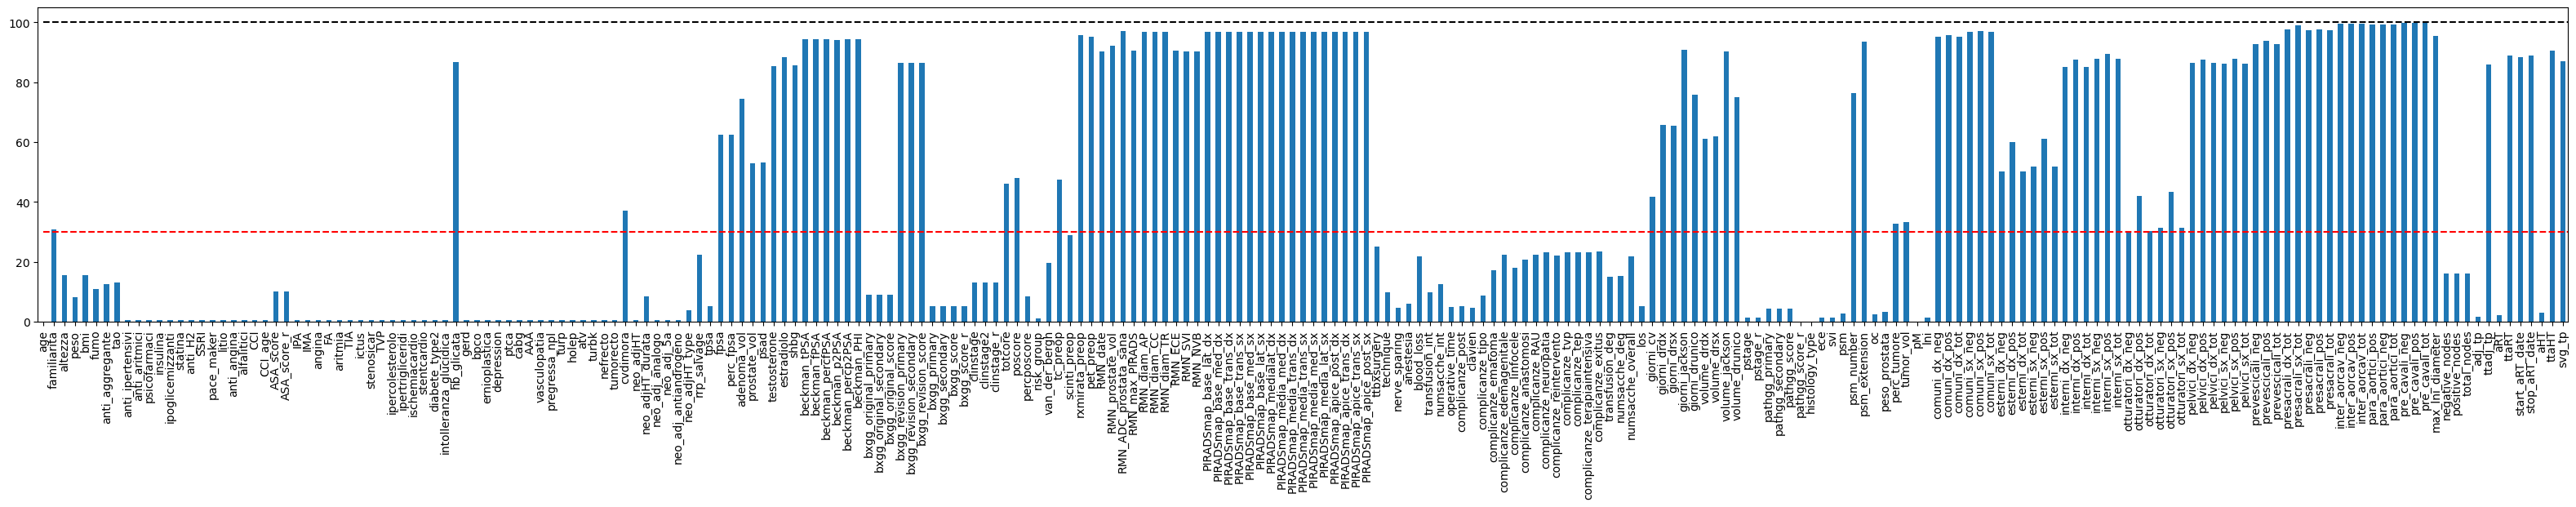

In [649]:
#Observe percentage (%) of missing values per feature. Red dashed line is a thresholed for removal

fig, ax = plt.subplots(figsize = (40,5))

removal_thres = 30

np.multiply(np.divide(np.sum(df_features.isna(), axis = 0), len(df_features)),100).plot(kind='bar')
ax.plot([0,len(df_features.columns)], [100, 100],  "k--")
ax.plot([0,len(df_features.columns)], [removal_thres, removal_thres], "r--")
fig.savefig('output.png', pad_inches = 0)

118 have been removed applying a missing values treshold of 30%. There are 121 features left


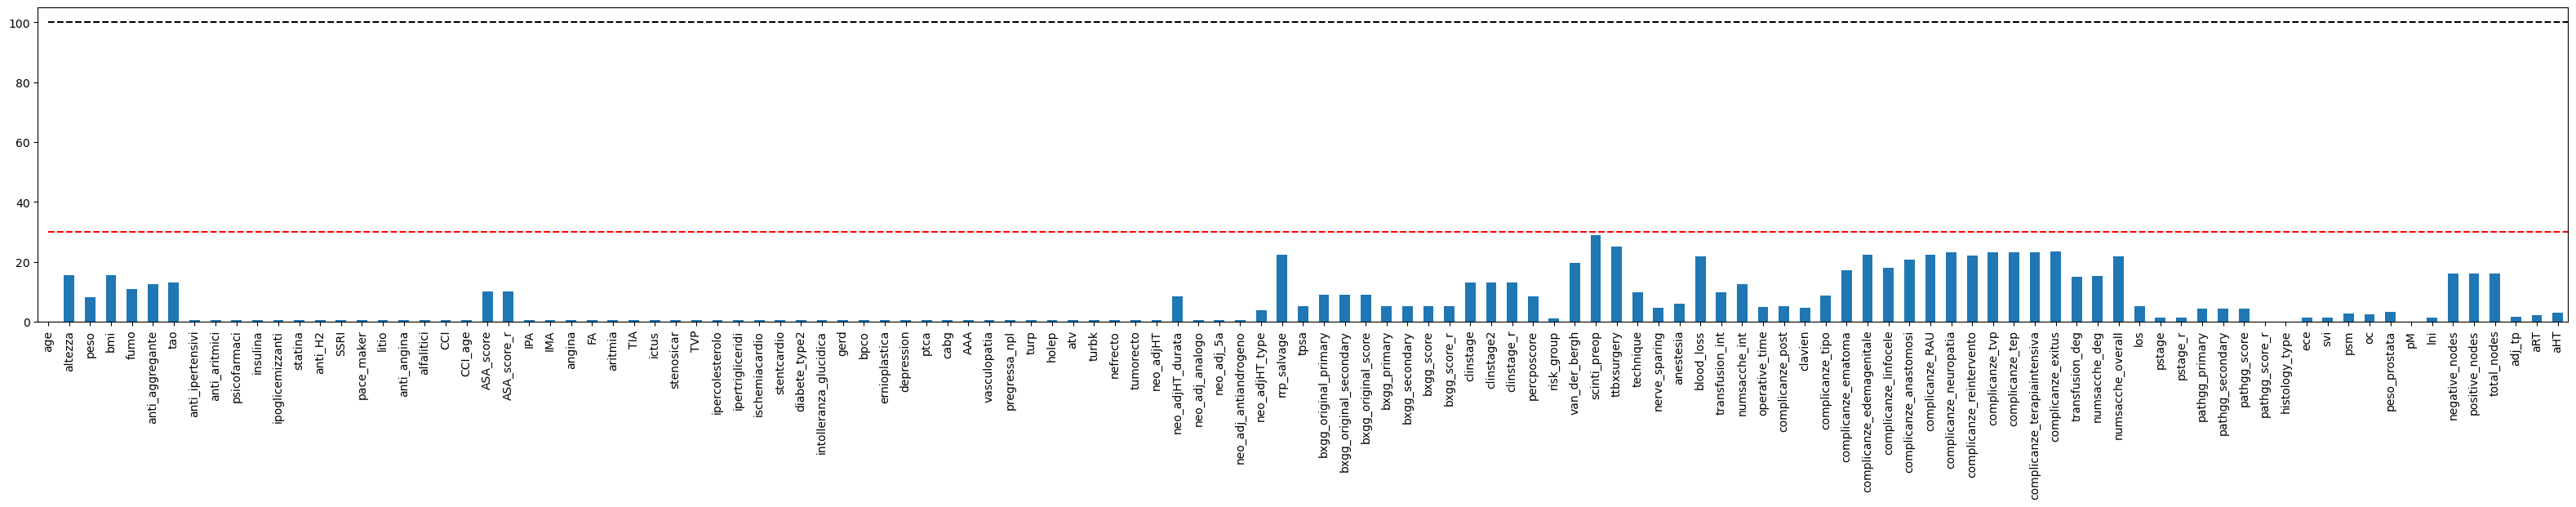

In [650]:
#Observe percentage (%) of missing values per feature AFTER removing features with large number of missing numbers. Red dashed line is a thresholed for removal

feature_removal_mask = np.multiply(np.divide(np.sum(df_features.isna(), axis = 0), len(df_features)),100) < removal_thres
df_features_trim = df_features.copy().loc[:,feature_removal_mask.values]
num_removed_features = len(df_features.columns) - len(df_features_trim.columns) 

print(f"{num_removed_features} have been removed applying a missing values treshold of {removal_thres}%. There are {len(df_features_trim.columns)} features left")

fig, ax = plt.subplots(figsize = (40,5))

np.multiply(np.divide(np.sum(df_features_trim.isna(), axis = 0), len(df_features_trim)),100).plot(kind='bar')
ax.plot([0,len(df_features_trim.columns)], [100, 100],  "k--")
ax.plot([0,len(df_features_trim.columns)], [removal_thres, removal_thres], "r--")

In [651]:
#show columns in dataframe that remained type object
df_features_trim.select_dtypes(include='object', exclude=None).head(5)

,neo_adjHT_type,clinstage2,complicanze_tipo,histology_type
patientID,,,,
7,Decapeptyl + Casodex,NaN,0,Adenocarcinoma acinare o non definito
53,None,NaN,1,Adenocarcinoma acinare o non definito
144,None,T1,0,Adenocarcinoma acinare o non definito
357,None,NaN,0,Adenocarcinoma acinare o non definito
451,None,NaN,1,Adenocarcinoma acinare o non definito


In [652]:
#See unique values for each variable of type object
df_features_type_object = df_features_trim.copy().select_dtypes(include='object', exclude=None)
df_features_type_object.apply(lambda col: len(col.unique())-1 if np.nan in list(col.unique()) else  len(col.unique()))

neo_adjHT_type      170
clinstage2            6
complicanze_tipo      9
histology_type        8
dtype: int64

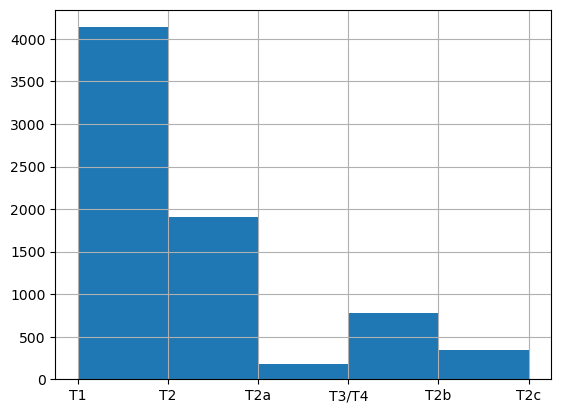

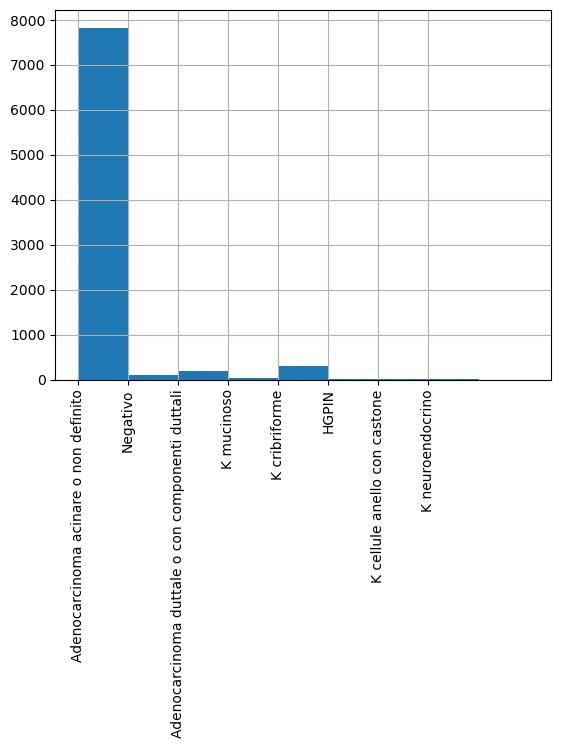

In [653]:
#clinstage2, complicanze_tipo and histology_type appear to be categorical, so lets see their distribution (ignore nan values)

df_features_trim.clinstage2.dropna().hist(bins = range(6))
plt.show()
df_features_trim.histology_type.dropna().hist( bins = range(10), xrot = 90)
plt.show()
#df_features_trim.complicanze_tipo.dropna().hist(bins = range(10))
#plt.show()

In [654]:
df_features_trim['bxgg_group'] = df_features_trim.apply(lambda x: get_gleason_group(x, gg_type = 'biopsy') , axis = 1)
df_features_trim['pathgg_group'] = df_features_trim.apply(lambda x: get_gleason_group(x, gg_type = 'path') , axis = 1)

In [655]:
#Check unique values for each variable to understand which ones are categorical (ignoring nan vals). A mask is created to filter categorical variables. 
#The used criteria is unique vals lower or equal to 10 (value based on Label Variables excel file)

categorical_mask = df_features_trim.apply(lambda col: len(col.unique())-1 if np.nan in list(col.unique()) else len(col.unique())) <= 10

df_features_trim.loc[:,categorical_mask.values] = df_features_trim.loc[:,categorical_mask.values].apply(pd.Categorical)

print(f"{df_features_trim.select_dtypes(include='object', exclude=None).columns.values} are still type object")

['neo_adjHT_type' 'clinstage2' 'complicanze_tipo' 'histology_type'] are still type object


C:\Users\airoso.alexandre\AppData\Local\Temp\ipykernel_11812\549119850.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[NaN, 0.0, NaN, 0.0, 2.0, ..., 0.0, 0.0, NaN, 0.0, 0.0]
Length: 8477
Categories (3, float64): [0.0, 1.0, 2.0]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_features_trim.loc[:,categorical_mask.values] = df_features_trim.loc[:,categorical_mask.values].apply(pd.Categorical)
C:\Users\airoso.alexandre\AppData\Local\Temp\ipykernel_11812\549119850.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[NaN, 0.0, 0.0, 0.0, 0.0, ..., NaN, NaN, NaN, NaN, NaN]
Length: 8477
Categories (2, float64): [0.0, 1.0]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_features_trim.loc[:,categorical_mask.values] = df_features_trim.loc[:,categorical_mask.v

In [656]:
#force conversion to categorical
df_features_trim.clinstage2 = pd.Categorical(df_features_trim.clinstage2)
df_features_trim.histology_type = pd.Categorical(df_features_trim.histology_type)

df_features_trim.drop('complicanze_tipo', axis = 1, inplace=True)



In [657]:
from string import digits
df_features_trim['neo_adjHT_type'] = df_features_trim['neo_adjHT_type'].astype('string')
print( f"There {len(df_features_trim['neo_adjHT_type'].unique())} unique values in neo_adjHT_type")

adj = df_features_trim['neo_adjHT_type'].apply(lambda k: ''.join([i for i in k.lower() if (i.isalnum()) & (not i.isdigit()) | (i == ' ')]) if not pd.isna(k) else pd.NA)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(adj.str.split().explode().value_counts())

#delete 'neo_adjHT_type' since most cases are 'none'
df_features_trim.drop('neo_adjHT_type', axis = 1, inplace=True)

There 171 unique values in neo_adjHT_type


neo_adjHT_type
none                        6972
casodex                      556
enantone                     178
eulexin                      124
decapeptyl                    93
dutasteride                   90
androcur                      70
bicalutamide                  56
casodexenantone               53
avodart                       28
finasteride                   27
zoladex                       26
casodexdecapeptyl             24
flutamide                     11
eulexinenantone               10
suprefact                      9
eligard                        7
e                              6
casodexsuprefact               6
androcurenantone               5
casodexzoladex                 5
apalutamide                    4
firmagon                       4
eulexindecapeptyl              3
enatone                        3
degarelix                      3
mg                             3
csodex                         2
triptorelina                   2
finastid                    

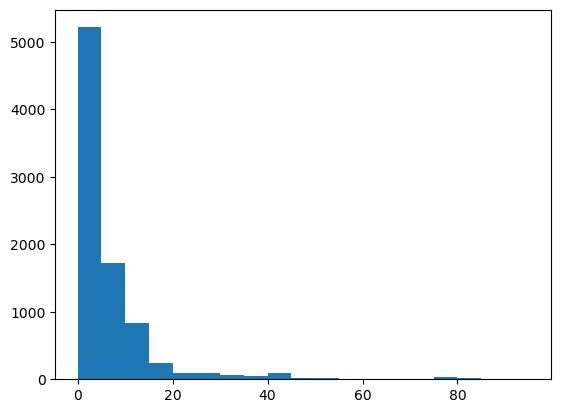

8477
471 lines will be removed
8006


In [658]:
#compute the percentage of nan values for each line and check its distribution to select a threshold for line removal

plt.hist(np.sum(df_features_trim.isna(), axis = 1)/len(df_features_trim.columns)*100, range(0,100,5))
plt.show()

line_removal_thres = 0.2

print(len(df_features_trim))

print(f"{np.sum(np.sum(df_features_trim.isna(), axis = 1)/len(df_features_trim.columns) > line_removal_thres)} lines will be removed" )

df_features_trim.dropna(thresh = (1 - line_removal_thres)*len(df_features_trim.columns), axis = 0, inplace=True) #remove lines according to nan count threshold
print(len(df_features_trim))

df_outcomes = df_outcomes.loc[df_features_trim.index] #update outcomes indices accordingly

In [659]:
#Number of positive, negative and total nodes can be summed up as percentage of positive nodes. 
df_features_trim['percposnodes'] = df_features_trim['positive_nodes']/df_features_trim['total_nodes']

In [660]:
#Get points according to primary and secondary gleason score for computing CAPRA score
df_features_trim['gleason_capra'] = df_features_trim.apply(get_gleason_capra, axis = 1).astype('category')


In [661]:
'''df_features_trim.drop(labels=[ 'bxgg_original_primary',
                              'bxgg_original_secondary',
                              'bxgg_original_score',
                              'bxgg_primary',
                              'bxgg_secondary',
                              'clinstage2',
                              'pathgg_primary',
                              'pathgg_secondary',
                              'clinstage2',
                              'positive_nodes',
                              'negative_nodes',
                              'total_nodes',
                              'otturatori_dx_neg',
                              'otturatori_dx_tot'], 
                              axis = 1, inplace = True)'''

df_features_trim.drop(labels=['positive_nodes',
                              'negative_nodes',
                              'total_nodes',
                              #'otturatori_dx_neg',
                              #'otturatori_dx_tot',
                              #'technique',
                              #'operative_time',
                              'rrp_salvage'],
                              #'los'], 
                              axis = 1, inplace = True)

In [662]:
#create column that stores the number of missing values per row and check its distribution 
#to decide which ones will be less altered by the imputation and thus use for val/test set
#df_features_trim['num_imputations'] = df_features_trim.isna().sum(axis = 1)
#df_features_trim['num_imputations'].hist(bins=20) 

In [663]:
#aTH (adjuvant HT) is not binary as the variable file indicates. It is hypothesized that it encodes the type of HT
df_features_trim['aHT'].unique()

[0.0, 3.0, 1.0, 2.0, NaN]
Categories (4, float64): [0.0, 1.0, 2.0, 3.0]

In [664]:
# One-hot encode histology_type 
hist_encoded = pd.get_dummies(df_features_trim['histology_type' ], prefix='histology_type'  , drop_first=True)

# Convert each column in hist_encoded to 'category' dtype
for col in hist_encoded.columns:
    hist_encoded[col] = hist_encoded[col].apply(lambda x: 1 if x else 0).astype('category')

# Remove columns that are all zeros
hist_encoded = hist_encoded.loc[:, (hist_encoded != 0).any(axis=0)]

# Drop the original column and merge the new one-hot encoded variables
df_features_trim = df_features_trim.drop(columns=['histology_type'  ]).join(hist_encoded)

# One-hot encode technique 
technique_encoded = pd.get_dummies(df_features_trim['technique' ], prefix='technique'  , drop_first=True)

# Convert each column in technique_encoded to 'category' dtype
for col in technique_encoded.columns:
    technique_encoded[col] = technique_encoded[col].apply(lambda x: 1 if x else 0).astype('category')

# Remove columns that are all zeros
technique_encoded = technique_encoded.loc[:, (technique_encoded != 0).any(axis=0)]

# Drop the original column and merge the new one-hot encoded variables
df_features_trim = df_features_trim.drop(columns=['technique'  ]).join(technique_encoded)

From here on i focus on cleaning and pre-processing the "outcomes" Dataframe

In [665]:
#Convert date of surgery (dos) and date of psa readings to datetime

df_psa = df_outcomes.loc[:,'psa_1':'psa_68']
df_psa_date = df_outcomes.loc[:,'date_psa_1':'date_psa_68']

df_outcomes["dos"] = pd.to_datetime(df_outcomes["dos"], format = '%Y-%m-%d')

wrong_date_vals = {'20013': '2013', '2919': '2019', '3013': '2013', '2917': '2017',
                   '2103': '2013', '2208': '2008', '2026': '2016', '2118': '2018',
                   '2201': '2014', '2029': '2020', '2200': '2009'} #substrings to correct

#replace wrong substrings
for k, v in wrong_date_vals.items():
    df_psa_date = df_psa_date.apply(lambda x: x.str.replace(k, v)) 

#convert dates to datetime format    
df_psa_date = df_psa_date.apply(lambda x: pd.to_datetime(x, format = '%Y-%m-%d') )

#calculate number of days since surgery
df_psa_days = df_psa_date.sub(df_outcomes["dos"], axis = 0).applymap(lambda x: x.days)

#indentify negative elements in number of days elapsed since surgery and substitute them with nan
psa_days_nan_indices = np.where(df_psa_days < 0)

for i,j in zip(psa_days_nan_indices[0], psa_days_nan_indices[1]):
    df_psa_days.iloc[i,j] = np.nan
    df_psa.iloc[i,j] = np.nan


#convert each row of psa and psa time values to a list of lists
psa_date_seq = np.asarray(df_psa_days).tolist()
psa_seq = np.asarray(df_psa).tolist()

#find all indices from psa time values that correspond to nan values and delete the corresponding indices from each list
psa_days_nan_indices = np.where(df_psa_days.isna())

for i in np.unique(psa_days_nan_indices[0]):
    to_remove = psa_days_nan_indices[1][psa_days_nan_indices[0] == i]
    psa_date_seq[i] =  np.delete(np.array(psa_date_seq[i]), to_remove).tolist()
    psa_seq[i] =  np.delete(np.array(psa_seq[i]), to_remove).tolist()

df_outcomes['psa_date_seq'] = psa_date_seq
df_outcomes['psa_seq'] = psa_seq

C:\Users\airoso.alexandre\AppData\Local\Temp\ipykernel_11812\2068341428.py:20: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_psa_days = df_psa_date.sub(df_outcomes["dos"], axis = 0).applymap(lambda x: x.days)


In [666]:
#sanity check to verify that, for each patient, the number of psa dates is equal to the number of psa values
pd.Series([len(x[0]) - len(x[1]) for x in zip(psa_seq, psa_date_seq)]).value_counts()

0    8006
Name: count, dtype: int64

In [667]:
#verify if the number of days are strictly increasing. Verify how many times consecutive values do not increase per row 
df_outcomes['psa_date_seq'].apply(lambda x: np.sum(np.diff(np.asarray(x))<0)).value_counts()

psa_date_seq
0     7471
1      438
2       59
3       17
6        5
5        4
4        4
10       3
11       2
7        1
9        1
8        1
Name: count, dtype: int64

In [668]:
#Get rid of elapsed days values that are lower than previous values (number of days should increase monotonically for each patient)

n_correct = 0

#loop until number of correct sequences is equal to the total number of sequences
while n_correct != df_outcomes['psa_date_seq'].count(): 
    #get indices where there is a decrease between two consecutive number of days
    decreasing_indeces = df_outcomes['psa_date_seq'].apply(lambda x: np.where(np.diff(np.asarray(x)) <= 0)[0])
    decreasing_indeces += 1   

    #Delete these values from psa_date_seq and corresponding values in psa_seq
    df_outcomes['psa_date_seq'] = df_outcomes['psa_date_seq'].to_frame(0).apply(lambda x: np.delete(np.asarray(x[0]), decreasing_indeces.loc[x.name]).tolist() if len(decreasing_indeces.loc[x.name]) > 0 else x[0], axis=1)
    df_outcomes['psa_seq'] = df_outcomes['psa_seq'].to_frame(0).apply(lambda x: np.delete(np.asarray(x[0]), decreasing_indeces.loc[x.name]).tolist() if len(decreasing_indeces.loc[x.name]) > 0 else x[0], axis=1)

    #update count of "correct" sequences, defined as having no decreases between two consecutive number of days
    n_correct = decreasing_indeces.apply(lambda x: len(x)).value_counts()[0]  

In [669]:
#verify if the number of days are strictly increasing. Very how many times consectutive values do not increase per row it occurs per row
#Since this was corrected in the previous cell, this value should be zero for all patients
df_outcomes['psa_date_seq'].apply(lambda x: np.sum(np.diff(np.asarray(x))<0)).value_counts()

psa_date_seq
0    8006
Name: count, dtype: int64

In [670]:
#Create new df for storing dynamic outcomes in a consistent format
df_outcomes_dyn = pd.DataFrame()

#Add stop times and psa vals
df_outcomes_dyn['stop'] = df_outcomes['psa_date_seq'].explode() 
df_outcomes_dyn['psa'] = df_outcomes['psa_seq'].explode() 

#Convert psa to numeric for later computations
df_outcomes_dyn['psa']  = pd.to_numeric(df_outcomes_dyn['psa'] )

In [671]:
#For each patient, set all psa values to nan after psa value >= 0.2 and remove them

psa_vals = df_outcomes_dyn.psa.copy()
for i in range(1,len(psa_vals)):
    if ((psa_vals.iloc[i-1] >= 0.2) | (pd.isna(psa_vals.iloc[i-1]))) & (psa_vals.index[i-1] == psa_vals.index[i]):
         psa_vals.iloc[i] = np.nan

    #extra if condition to filter out follow ups done later than 15 years
    #if df_outcomes_dyn.stop.iloc[i-1] > 15*365:
    #     psa_vals.iloc[i] = np.nan

df_outcomes_dyn.psa = psa_vals
df_outcomes_dyn.dropna(axis = 0, inplace = True)

In [672]:
df_outcomes_dyn['bcr'] = df_outcomes_dyn.psa.apply(lambda x: 1 if x >= 0.2 else 0) 
df_outcomes_dyn.head(20)
df_outcomes_dyn.to_csv('df_outcomes.csv')

df_outcomes['bcr'] = df_outcomes_dyn.groupby(level=0).bcr.last()


In [673]:
#create start time column
df_indices =  df_outcomes_dyn.index.unique()
start_times = list()

for index in df_indices: 
    start_times.append(0)
    stop_times = df_outcomes_dyn.loc[index, 'stop']
    if type(stop_times) is pd.core.series.Series:
        start_times.extend(stop_times.tolist()[:-1])

df_outcomes_dyn['start'] = start_times
df_outcomes_dyn = df_outcomes_dyn[['start','stop','bcr','psa']]


In [674]:
df_outcomes['psa_date_seq'].to_frame(0).apply(lambda x: print(x[0]), axis=1)

[3955.0]
[4396.0, 4499.0]
[3097.0]
[3724.0]
[1818.0]
[2081.0, 4189.0]
[2603.0, 4246.0, 4489.0]
[175.0, 2419.0, 3151.0, 3613.0]
[1689.0, 3169.0]
[4641.0]
[1909.0, 3363.0, 3630.0, 4466.0, 5227.0, 5493.0, 5850.0, 6460.0]
[349.0, 626.0, 774.0, 970.0, 1352.0, 1691.0, 2297.0, 2681.0, 3171.0, 3531.0, 5440.0]
[1000.0]
[2734.0, 4056.0, 4420.0]
[2195.0]
[4166.0, 5847.0]
[2473.0]
[38.0, 99.0, 477.0, 724.0, 834.0, 1043.0, 1612.0, 1760.0, 2150.0, 2339.0, 2493.0, 2719.0, 2856.0, 3137.0]
[3517.0]
[267.0, 946.0, 1746.0, 2193.0]
[3675.0]
[637.0, 742.0, 942.0, 1081.0, 1250.0, 1294.0, 1504.0, 1642.0, 1859.0, 2048.0, 2234.0, 2352.0, 2537.0, 2806.0, 3150.0, 3293.0, 3560.0, 3895.0, 4069.0, 4281.0, 4635.0, 4861.0, 5551.0, 5627.0, 6150.0, 6463.0]
[1998.0]
[667.0]
[3631.0]
[1474.0, 2752.0, 3114.0]
[561.0, 962.0, 1570.0, 2247.0, 2906.0]
[2902.0, 3829.0]
[466.0, 1677.0, 2696.0, 3048.0, 3465.0, 3790.0, 4131.0, 4518.0, 4775.0, 4987.0, 5148.0, 5335.0, 5701.0]
[913.0, 1363.0, 2950.0, 4328.0]
[362.0, 580.0]
[52.0]
[2

patientID
7          None
53         None
144        None
357        None
451        None
           ... 
2033407    None
2033418    None
2033421    None
2033423    None
2033445    None
Length: 8006, dtype: object

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'altezza'}>,
        <Axes: title={'center': 'peso'}>,
        <Axes: title={'center': 'bmi'}>],
       [<Axes: title={'center': 'neo_adjHT_durata'}>,
        <Axes: title={'center': 'tpsa'}>,
        <Axes: title={'center': 'percposcore'}>,
        <Axes: title={'center': 'ttbxsurgery'}>],
       [<Axes: title={'center': 'blood_loss'}>,
        <Axes: title={'center': 'numsacche_int'}>,
        <Axes: title={'center': 'operative_time'}>,
        <Axes: title={'center': 'numsacche_deg'}>],
       [<Axes: title={'center': 'numsacche_overall'}>,
        <Axes: title={'center': 'los'}>,
        <Axes: title={'center': 'peso_prostata'}>,
        <Axes: title={'center': 'percposnodes'}>]], dtype=object)

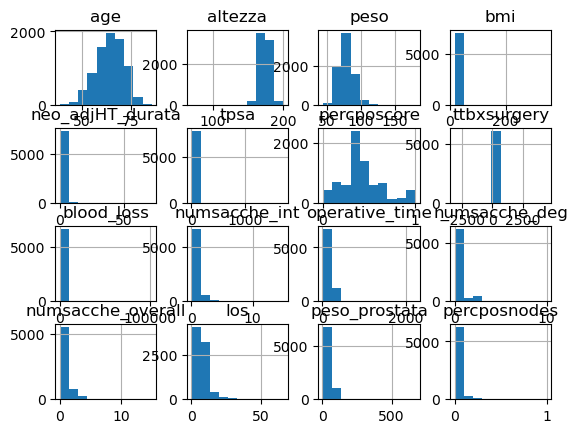

In [675]:
#check if continuous vars have normal distribution
df_features_trim.select_dtypes(include='number').hist()

In [676]:
#check indices where start and stop times are the same
indices2remove = np.where(df_outcomes_dyn['start'] ==  df_outcomes_dyn['stop'])[0]
indices2remove

array([14028, 15754, 18794], dtype=int64)

In [677]:
#remove indices where start and stop times are the same
df_outcomes_dyn['patientID'] = df_outcomes_dyn.index
df_outcomes_dyn.reset_index(drop=True, inplace=True)
df_outcomes_dyn.drop(indices2remove.tolist(),inplace=True)
df_outcomes_dyn.set_index('patientID', inplace=True)

In [678]:
#sanity check indices where start and stop times are the same
np.where(df_outcomes_dyn['start'] ==  df_outcomes_dyn['stop'])[0]

array([], dtype=int64)

In [679]:
#Set T MAX as 15 years
df_outcomes_dyn = df_outcomes_dyn[df_outcomes_dyn['stop'] <= 15*365]

In [680]:
#keep patients with more than 1 FUP

index_counts = df_outcomes_dyn.index.value_counts()
indexes_to_keep = index_counts[index_counts > 1].index
df_features_trim = df_features_trim[df_features_trim.index.isin(indexes_to_keep)]
df_outcomes_dyn = df_outcomes_dyn[df_outcomes_dyn.index.isin(indexes_to_keep)]

print(f'Total of {len(np.unique(df_outcomes_dyn.index))} patients in the final dataset')

Total of 3971 patients in the final dataset


In [681]:
#remove "cat" versions of other variables to avoid multicolinearity
'''for col in df_features_trim.columns:
    if col[-2:] == '_r':
        df_features_trim.drop(col, axis = 1, inplace=True)'''

"for col in df_features_trim.columns:\n    if col[-2:] == '_r':\n        df_features_trim.drop(col, axis = 1, inplace=True)"

In [682]:
#Before imputation, separate into train- val- and test-set


df_features_trim, df_outcomes = df_features_trim.loc[df_outcomes_dyn.index.unique()], df_outcomes.loc[df_outcomes_dyn.index.unique()]

#Alternatively, perform regular train/val/test split with 80/10/10%
X_train, X_hold, y_train, y_hold = train_test_split(df_features_trim, df_outcomes, test_size=0.20, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_hold, y_hold, test_size=0.50, stratify = y_hold.bcr, random_state=42)

#get dynamic outcomes for each set
y_train = df_outcomes_dyn.loc[y_train.index]
y_val = df_outcomes_dyn.loc[y_val.index]
y_test = df_outcomes_dyn.loc[y_test.index]

#Join outcomes and features dataframes
X_train = y_train.join(X_train)
X_val = y_val.join(X_val)
X_test = y_test.join(X_test)

X_full = df_outcomes_dyn.join(df_features_trim)
X_full.to_csv('full_dataset_clean.csv')

In [683]:
'''# Use indices from previous split to form train, val and test sets

train_indices = pd.read_csv('train_bcr.csv')["patientID"].unique()
val_indices = pd.read_csv('val_bcr.csv')["patientID"].unique()
test_indices = pd.read_csv('test_bcr.csv')["patientID"].unique()

y_train = df_outcomes_dyn.loc[train_indices]
y_val = df_outcomes_dyn.loc[val_indices]
y_test = df_outcomes_dyn.loc[test_indices]

X_train = df_features_trim.loc[train_indices]
X_val = df_features_trim.loc[val_indices]
X_test = df_features_trim.loc[test_indices]

#Join outcomes and features dataframes
X_train = y_train.join(X_train)
X_val = y_val.join(X_val)
X_test = y_test.join(X_test)'''

'# Use indices from previous split to form train, val and test sets\n\ntrain_indices = pd.read_csv(\'train_bcr.csv\')["patientID"].unique()\nval_indices = pd.read_csv(\'val_bcr.csv\')["patientID"].unique()\ntest_indices = pd.read_csv(\'test_bcr.csv\')["patientID"].unique()\n\ny_train = df_outcomes_dyn.loc[train_indices]\ny_val = df_outcomes_dyn.loc[val_indices]\ny_test = df_outcomes_dyn.loc[test_indices]\n\nX_train = df_features_trim.loc[train_indices]\nX_val = df_features_trim.loc[val_indices]\nX_test = df_features_trim.loc[test_indices]\n\n#Join outcomes and features dataframes\nX_train = y_train.join(X_train)\nX_val = y_val.join(X_val)\nX_test = y_test.join(X_test)'

In [684]:
#impute and scale train, val and test sets
X_val = impute_and_scale(X_val, X_train)
X_test = impute_and_scale(X_test, X_train)
X_train = impute_and_scale(X_train, X_train)

In [685]:
idxs = X_train.select_dtypes('category').nunique().sort_values(ascending = False) > 2
X_train.select_dtypes('category').nunique().sort_values(ascending = False)[idxs]

bxgg_original_score        9
pathgg_score               9
bxgg_score                 9
CCI_age                    9
pstage                     8
clinstage2                 6
CCI                        6
clavien                    6
pathgg_group               5
bxgg_original_primary      5
bxgg_primary               5
bxgg_secondary             5
bxgg_original_secondary    5
pathgg_primary             5
pathgg_secondary           5
bxgg_group                 5
pstage_r                   4
adj_tp                     4
ASA_score                  4
clinstage                  4
aHT                        4
risk_group                 3
clinstage_r                3
bxgg_score_r               3
gleason_capra              3
pathgg_score_r             3
pM                         3
fumo                       3
ASA_score_r                3
dtype: int64

In [686]:
#Save train, val, test as .csv
X_train.to_csv('train_bcr_no_dummies.csv')
X_val.to_csv('val_bcr_no_dummies.csv')
X_test.to_csv('test_bcr_no_dummies.csv')

In [687]:
#compute follow up statistics 
def get_stats(X):
    count_1_fup, count_mult_fup = 0, 0
    n_fup ,fup1_psa_vals, fup1_time_vals, total_fup_times, fup_b4_bcr_psa_vals = list(), list(), list(), list(), list()
    n_3y_fup, n_5y_fup, n_10y_fup, n_15y_fup  = 0, 0, 0, 0 

    X = X.copy()

    X.stop = (X.stop/30).apply(round)
    X.start = (X.start/30).apply(round)

    for i in np.unique(X.index):
        if np.max(X.stop.loc[i]) > 15*12:
            n_15y_fup += 1
        if np.max(X.stop.loc[i]) >= 10*12:
            n_10y_fup += 1
        if np.max(X.stop.loc[i]) >= 5*12:
            n_5y_fup += 1
        if np.max(X.stop.loc[i]) >= 3*12:
            n_3y_fup += 1

        if len(X.loc[i].shape) == 2:
            count_mult_fup +=1
            n_fup.append(X.loc[i].shape[0])
            fup1_psa_vals.append(X.psa.loc[i].iloc[0])
            fup1_time_vals.append(X.stop.loc[i].iloc[0])
            total_fup_times.append(X.stop.loc[i].iloc[-1])
            fup_b4_bcr_psa_vals.append(X.psa.loc[i].iloc[-2])
        else: 
            count_1_fup +=1
            n_fup.append(1)
            fup1_psa_vals.append(X.psa.loc[i])
            fup1_time_vals.append(X.stop.loc[i])
            total_fup_times.append(X.stop.loc[i])
            fup_b4_bcr_psa_vals.append(np.nan)


    print('Patients with 1 follow-up: ',count_1_fup)
    print('Patients with more than 1 follow-up: ', count_mult_fup)

    fup_intervals = (X.stop - X.start)
    fup1_psa_med = np.median(fup1_psa_vals)
    total_fup_times_med = np.median(total_fup_times)
    fup1_time_vals_med = np.median(fup1_time_vals)

    perc_3y_fup = (n_3y_fup/len(np.unique(X.index)))*100
    perc_5y_fup = (n_5y_fup/len(np.unique(X.index)))*100
    perc_10y_fup = (n_10y_fup/len(np.unique(X.index)))*100
    perc_15y_fup = (n_15y_fup/len(np.unique(X.index)))*100

    n_bcr = X.bcr.sum()
    perc_bcr = round(n_bcr*100/(count_mult_fup + count_1_fup))

    print(f"median interval between follow ups is {fup_intervals.median()} months, (Q1:,{np.quantile(fup_intervals, .25)} Q3:{np.quantile(fup_intervals, .75)})")
    print(f"median number of follow ups per patient is {np.median(n_fup)}, (Q1:,{np.quantile(n_fup, .25)} Q3:{np.quantile(n_fup, .75)})")
    print(f"median of the psa value in the 1st follow-up is {fup1_psa_med}, , (Q1:{np.quantile(fup1_psa_vals, .25)} Q3:{np.quantile(fup1_psa_vals, .75)})")
    print(f"median of the total follow up time is is {total_fup_times_med}, , (Q1:{np.quantile(total_fup_times, .25)} Q3:{np.quantile(total_fup_times, .75)})")
    print(f"median time until 1st follow up is {fup1_time_vals_med}, , (Q1:{np.quantile(fup1_time_vals, .25)} Q3:{np.quantile(fup1_time_vals, .75)})")
    print(f"a total of {n_bcr} ({perc_bcr}%) patients had BCR")
    print(f"median time until BCR is {X[X.bcr == 1].stop.median()}, , (Q1:{np.quantile(X[X.bcr == 1].stop, .25)} Q3:{np.quantile(X[X.bcr == 1].stop, .75)})")
    print(f"3-, 5-, 10- and 15-years follow-up data is available for {perc_3y_fup}%, {perc_5y_fup}%, {perc_10y_fup}%, {perc_15y_fup}%")

    return fup1_psa_vals, fup_b4_bcr_psa_vals, total_fup_times, n_fup


In [688]:
get_stats(X_full)

Patients with 1 follow-up:  0
Patients with more than 1 follow-up:  3971
median interval between follow ups is 12.0 months, (Q1:,6.0 Q3:18.0)
median number of follow ups per patient is 3.0, (Q1:,2.0 Q3:6.0)
median of the psa value in the 1st follow-up is 0.01, , (Q1:0.01 Q3:0.03)
median of the total follow up time is is 64.0, , (Q1:34.0 Q3:109.0)
median time until 1st follow up is 9.0, , (Q1:3.0 Q3:29.0)
a total of 626 (16%) patients had BCR
median time until BCR is 58.0, , (Q1:29.0 Q3:92.0)
3-, 5-, 10- and 15-years follow-up data is available for 73.48274993704356%, 54.52027197179552%, 20.926718710652228%, 0.8310249307479225%


([0.04,
  0.04,
  0.01,
  0.0,
  0.04,
  0.01,
  0.01,
  0.01,
  0.01,
  0.01,
  0.0,
  0.04,
  0.01,
  0.0,
  0.01,
  0.0,
  0.01,
  0.0,
  0.05,
  0.0,
  0.01,
  0.05,
  0.01,
  0.01,
  0.01,
  0.06,
  0.0,
  0.15,
  0.03,
  0.05,
  0.01,
  0.19,
  0.03,
  0.01,
  0.01,
  0.01,
  0.01,
  0.01,
  0.14,
  0.01,
  0.01,
  0.01,
  0.02,
  0.0,
  0.01,
  0.09,
  0.0,
  0.1,
  0.04,
  0.01,
  0.01,
  0.01,
  0.16,
  0.04,
  0.0,
  0.02,
  0.01,
  0.01,
  0.02,
  0.04,
  0.0,
  0.01,
  0.1,
  0.02,
  0.01,
  0.01,
  0.04,
  0.0,
  0.01,
  0.02,
  0.03,
  0.04,
  0.01,
  0.04,
  0.01,
  0.0,
  0.01,
  0.02,
  0.02,
  0.02,
  0.02,
  0.02,
  0.03,
  0.0,
  0.01,
  0.01,
  0.01,
  0.0,
  0.01,
  0.01,
  0.05,
  0.01,
  0.01,
  0.06,
  0.0,
  0.01,
  0.0,
  0.01,
  0.01,
  0.01,
  0.02,
  0.01,
  0.02,
  0.04,
  0.01,
  0.01,
  0.0,
  0.01,
  0.03,
  0.0,
  0.05,
  0.16,
  0.02,
  0.01,
  0.01,
  0.01,
  0.01,
  0.0,
  0.04,
  0.0,
  0.01,
  0.01,
  0.08,
  0.0,
  0.04,
  0.01,
  0.03,
  0.01,
